# Bio RealNVP contours

Push forward Gaussian ball boundaries through the pretrained conditional RealNVP model.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import chi2

REPOSITORY_ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src").is_dir()
)
sys.path.insert(0, str(REPOSITORY_ROOT / "src"))

from configs.datasets.real import BioDatasetConfig
from configs.predictors.transport import NormalizingFlowPredictorConfig
from data.datasets.real import BioDataset
from predictors.transport import NormalizingFlowPredictor

CHECKPOINT_PATH = REPOSITORY_ROOT / "benchmark/downloads/bio_seed_0/base/predictor.pt"
RANDOM_SEED = 7
N_COVARIATES = 6
BOUNDARY_POINTS = 400
DENSITY_GRID_SIZE = 220

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [2]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
model_config = NormalizingFlowPredictorConfig.model_validate(
    {**checkpoint["config"], "device": "cpu"}
)
predictor = NormalizingFlowPredictor(model_config)
predictor.load_state_dict(checkpoint["state_dict"])
predictor.eval()

dataset = BioDataset(
    BioDatasetConfig(seed=0, device="cpu", dtype="float32")
)
test_data = dataset.get_splits().test

In [3]:
def gaussian_ball_boundary(mass, n_points=BOUNDARY_POINTS):
    radius = np.sqrt(chi2.ppf(mass, df=2))
    angles = torch.linspace(0, 2 * torch.pi, n_points + 1)
    return radius * torch.stack((torch.cos(angles), torch.sin(angles)), dim=1)


@torch.inference_mode()
def pushforward_contour(x, mass):
    u = gaussian_ball_boundary(mass)
    x_batch = x.unsqueeze(0).expand(u.shape[0], -1)
    return predictor.pushforward(x=x_batch, u=u).cpu().numpy()


def padded_bounds(contours, padding=0.12):
    points = np.concatenate(contours, axis=0)
    lower = points.min(axis=0)
    upper = points.max(axis=0)
    margin = padding * (upper - lower)
    return lower - margin, upper + margin


@torch.inference_mode()
def density_grid(x, lower, upper, grid_size=DENSITY_GRID_SIZE):
    f7 = np.linspace(lower[0], upper[0], grid_size)
    f9 = np.linspace(lower[1], upper[1], grid_size)
    f7_grid, f9_grid = np.meshgrid(f7, f9)
    y_grid = torch.tensor(
        np.column_stack((f7_grid.ravel(), f9_grid.ravel())),
        dtype=torch.float32,
    )

    values = []
    for y_batch in y_grid.split(8192):
        x_batch = x.unsqueeze(0).expand(y_batch.shape[0], -1)
        values.append(predictor.log_prob(x=x_batch, y=y_batch).exp().cpu())

    density = torch.cat(values).reshape(grid_size, grid_size).numpy()
    return f7_grid, f9_grid, density

## 50% Gaussian-ball pushforwards for test covariates

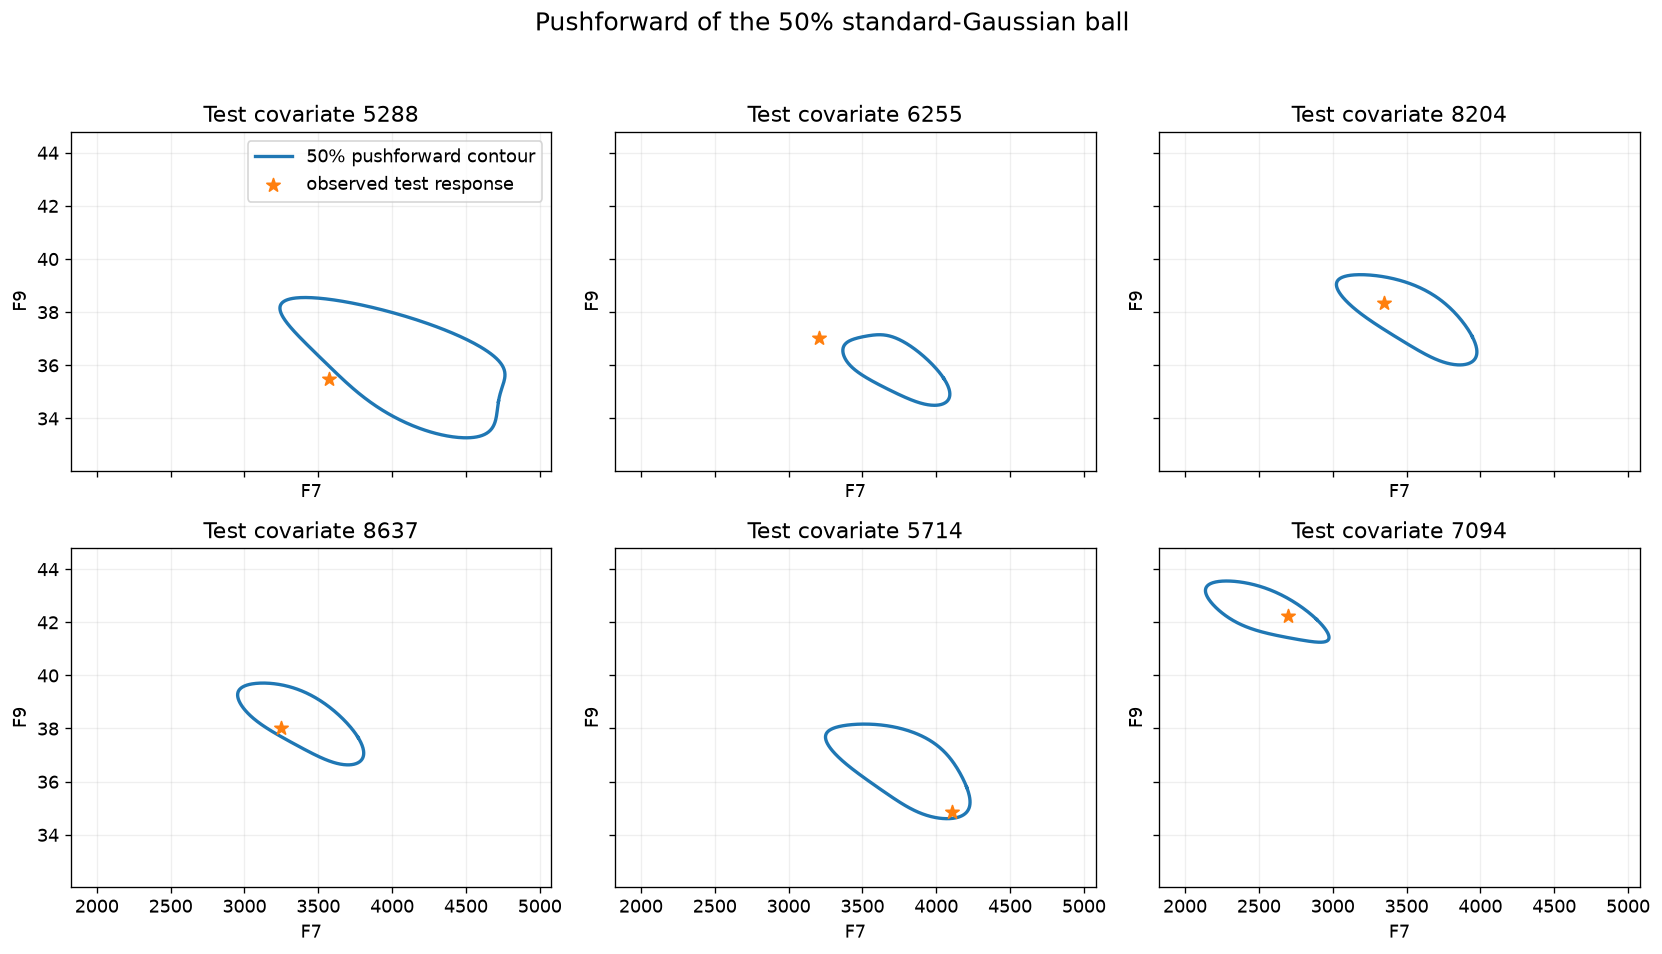

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
test_indices = rng.choice(len(test_data.x), size=N_COVARIATES, replace=False)
contours_50 = [
    pushforward_contour(test_data.x[index], mass=0.50)
    for index in test_indices
]
lower, upper = padded_bounds(contours_50)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
for axis, index, contour in zip(axes.flat, test_indices, contours_50):
    observed_y = test_data.y[index].cpu().numpy()
    axis.plot(contour[:, 0], contour[:, 1], color="tab:blue", linewidth=2)
    axis.scatter(*observed_y, color="tab:orange", marker="*", s=70, zorder=3)
    axis.set_title(f"Test covariate {index}")
    axis.set_xlabel("F7")
    axis.set_ylabel("F9")
    axis.set_xlim(lower[0], upper[0])
    axis.set_ylim(lower[1], upper[1])
    axis.grid(alpha=0.2)

fig.suptitle("Pushforward of the 50% standard-Gaussian ball", fontsize=15, y=0.99)
axes.flat[0].legend(
    ["50% pushforward contour", "observed test response"],
    loc="upper right",
)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## Nested pushforward contours and learned density

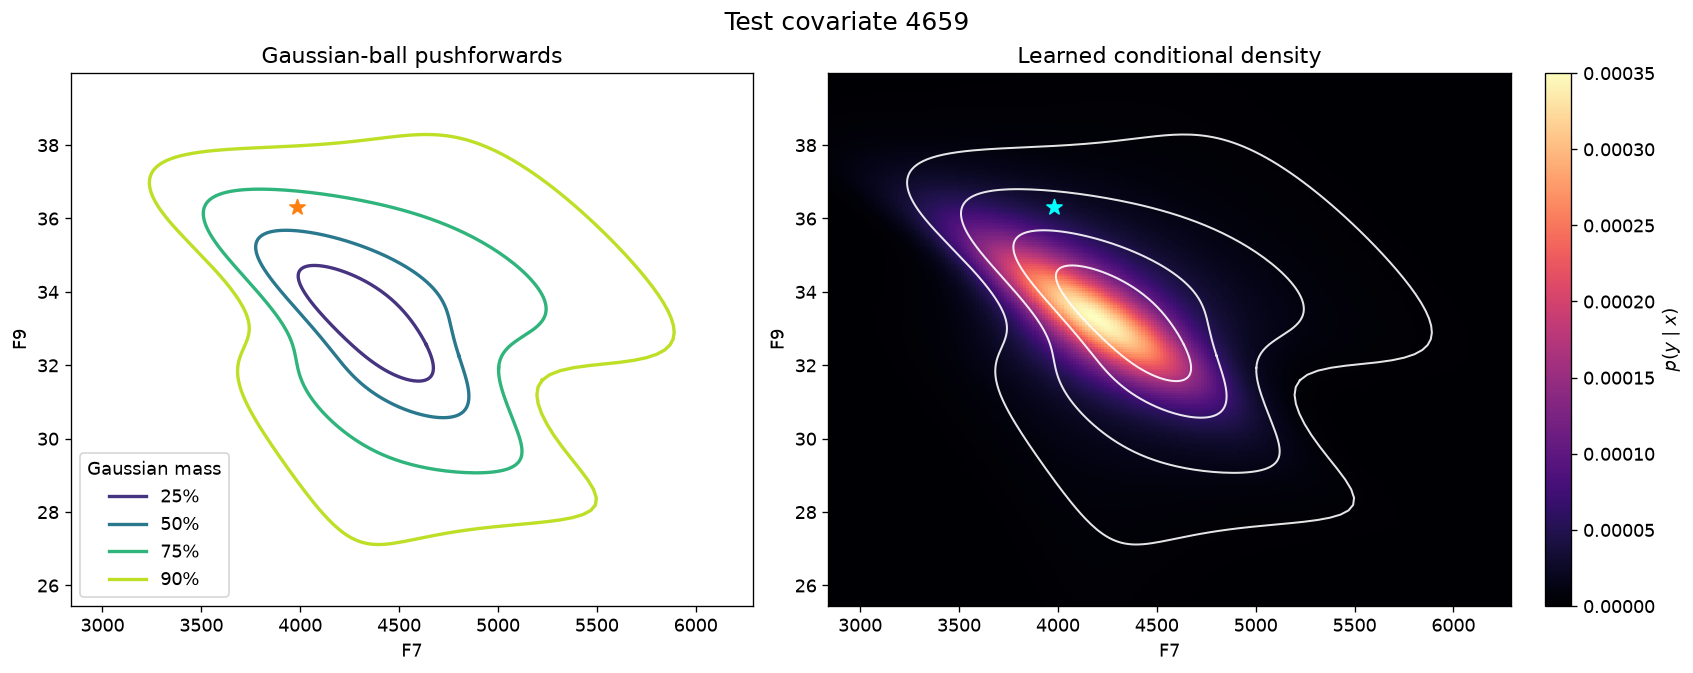

In [26]:
masses = (0.25, 0.50, 0.75, 0.90)
selected_index = int(rng.choice(len(test_data.x)))
selected_x = test_data.x[selected_index]
selected_y = test_data.y[selected_index].cpu().numpy()
contours = {mass: pushforward_contour(selected_x, mass) for mass in masses}
lower, upper = padded_bounds(list(contours.values()), padding=0.15)
f7_grid, f9_grid, density = density_grid(selected_x, lower, upper)
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(masses)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

for mass, color in zip(masses, colors):
    contour = contours[mass]
    axes[0].plot(contour[:, 0], contour[:, 1], color=color, linewidth=2, label=f"{mass:.0%}")
axes[0].scatter(*selected_y, color="tab:orange", marker="*", s=90, zorder=3)
axes[0].set_title("Gaussian-ball pushforwards")
axes[0].legend(title="Gaussian mass")

heatmap = axes[1].pcolormesh(
    f7_grid,
    f9_grid,
    density,
    shading="auto",
    cmap="magma",
)
for mass in masses:
    contour = contours[mass]
    axes[1].plot(contour[:, 0], contour[:, 1], color="white", linewidth=1.2, alpha=0.9)
axes[1].scatter(*selected_y, color="cyan", marker="*", s=90, zorder=3)
axes[1].set_title("Learned conditional density")
fig.colorbar(heatmap, ax=axes[1], label=r"$p(y \mid x)$")

for axis in axes:
    axis.set_xlabel("F7")
    axis.set_ylabel("F9")
    axis.set_xlim(lower[0], upper[0])
    axis.set_ylim(lower[1], upper[1])

fig.suptitle(f"Test covariate {selected_index}", fontsize=15)
plt.show()